In [3]:
import numpy as np
import os
dataset_path = "/kaggle/input/garbage-dataset/garbage_classification"
classes = os.listdir(dataset_path)
print (f"Classes found: {classes}")
image_paths, labels = [], []
for label, class_name in enumerate(classes):
    class_dir = os.path.join(dataset_path, class_name)
    for img_name in os.listdir(class_dir):
        image_paths.append(os.path.join(class_dir, img_name))
        labels.append(label)

Classes found: ['metal', 'Plastic-bag', 'white-glass', 'biological', 'paper', 'battery', 'trash', 'cardboard', 'shoes', 'clothes', 'Bottle']


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
import cv2
import tensorflow as tf
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
from skimage import feature
import numpy as np
import warnings
warnings.filterwarnings('ignore')

2026-01-19 12:36:17.323256: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768826177.564124      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768826177.631184      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768826178.174199      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768826178.174240      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768826178.174242      55 computation_placer.cc:177] computation placer alr

In [5]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

# CẤU HÌNH THAM SỐ
MODEL_NAME = 'efficientnet_b0'
FEATURE_DIMENSION = 1280 # Chiều đầu ra của lớp pooling trước lớp phân loại
RESIZE_SIZE = 224        # Kích thước ảnh đầu vào tiêu chuẩn của EfficientNet
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. TẢI MÔ HÌNH VÀ CẤU HÌNH TIỀN XỬ LÝ
try:
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    
    # Loại bỏ lớp phân loại cuối cùng (classifier)
    # Chúng ta chỉ lấy đến lớp Global Average Pooling để có vector 1280 chiều
    model.classifier = torch.nn.Identity()
    
    model.to(DEVICE)
    model.eval() # Đặt mô hình ở chế độ đánh giá (quan trọng cho feature extraction)
    print(f"Đã tải mô hình {MODEL_NAME} và sẵn sàng trích xuất đặc trưng.")

except Exception as e:
    print(f"Lỗi tải EfficientNet: {e}")
    exit()

# Định nghĩa các bước tiền xử lý cần thiết cho EfficientNet
preprocess_transform = transforms.Compose([
    transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    transforms.ToTensor(), # Chuyển ảnh PIL/numpy sang Tensor
    # Chuẩn hóa theo tiêu chuẩn của ImageNet (để khớp với quá trình huấn luyện EfficientNet)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# =========================================================
# 2. HÀM TRÍCH XUẤT ĐẶC TRƯNG
# =========================================================
def get_efficientnet_features(image_path):
    """
    Trích xuất vector đặc trưng 1280 chiều từ ảnh bằng EfficientNetB0.
    """
    try:
        # 1. Đọc ảnh (dùng PIL cho PyTorch)
        image = Image.open(image_path).convert('RGB')
        
        # 2. Tiền xử lý và chuyển sang Tensor
        image_tensor = preprocess_transform(image).unsqueeze(0).to(DEVICE)
        
        # 3. Trích xuất đặc trưng
        with torch.no_grad():
            features = model(image_tensor)
        
        # 4. Trả về NumPy array đã làm phẳng (1280D)
        return features.cpu().numpy().flatten()

    except Exception as e:
        # print(f"Lỗi xử lý ảnh {image_path}: {e}")
        return None



Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 145MB/s]


Đã tải mô hình efficientnet_b0 và sẵn sàng trích xuất đặc trưng.


In [6]:
efficientnet_features_list = []
valid_labels = []
valid_image_paths = [] # <--- KHAI BÁO VÀ THU THẬP ĐƯỜNG DẪN HỢP LỆ

print(f"Bắt đầu trích xuất EfficientNet features cho {len(image_paths)} ảnh...")

for idx, (img_path, label) in enumerate(zip(image_paths, labels)):
    if idx % 500 == 0:
        pass
    
    feat = get_efficientnet_features(img_path) 
    
    if feat is not None:
        efficientnet_features_list.append(feat)
        valid_labels.append(label)
        valid_image_paths.append(img_path)

X = np.array(efficientnet_features_list)
y = np.array(valid_labels)

print(f"\n✅ Hoàn thành trích xuất. Kích thước X: {X.shape}, y: {y.shape}")

Bắt đầu trích xuất EfficientNet features cho 15376 ảnh...

✅ Hoàn thành trích xuất. Kích thước X: (15376, 1280), y: (15376,)


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import numpy as np

TEST_SIZE_RATIO = 0.2 
VALID_SIZE_RATIO = 0.2 

# BƯỚC 1: CHIA TRAIN VÀ TẠM THỜI (TEMP)

temp_size = TEST_SIZE_RATIO + VALID_SIZE_RATIO 

X_train, X_temp, y_train, y_temp, paths_train, paths_temp = train_test_split(
    X, 
    y, 
    valid_image_paths, 
    test_size=temp_size, 
    random_state=42, 
    stratify=y
)

valid_test_ratio = TEST_SIZE_RATIO / temp_size 

X_valid, X_test, y_valid, y_test, paths_valid, paths_test = train_test_split(
    X_temp, 
    y_temp, 
    paths_temp,
    test_size=valid_test_ratio, 
    random_state=42, 
    stratify=y_temp 
)

scaler = StandardScaler() 

# 1. FIT và TRANSFORM trên tập TRAIN
X_train_scaled = scaler.fit_transform(X_train) 

# 2. CHỈ TRANSFORM trên tập VALID và TEST (Dùng tham số từ tập TRAIN)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

print(f"Mean của X_train_scaled (nên gần 0): {X_train_scaled.mean():.4f}")
print(f"Std dev của X_train_scaled (nên gần 1): {X_train_scaled.std():.4f}")

# 3. LƯU SCALER CHO DEMO WEB (Bắt buộc)
joblib.dump(scaler, 'scaler_efficientnet_features.joblib')
print("Đã lưu scaler vào 'scaler_efficientnet_features.joblib'.")

# BƯỚC 4: KIỂM TRA KÍCH THƯỚC VÀ CHUẨN BỊ CHO SVM

print("KÍCH THƯỚC CÁC TẬP DỮ LIỆU ĐÃ CHUẨN HÓA:")
print(f"1. Tập Huấn luyện (Train) size: {X_train_scaled.shape[0]} ({X_train_scaled.shape[0]/X.shape[0]:.2%})")
print(f"2. Tập Thẩm định (Valid) size: {X_valid_scaled.shape[0]} ({X_valid_scaled.shape[0]/X.shape[0]:.2%})")
print(f"3. Tập Kiểm thử (Test) size: {X_test_scaled.shape[0]} ({X_test_scaled.shape[0]/X.shape[0]:.2%})")
print(f"Feature dimensions: {X_train_scaled.shape[1]}")

# Dữ liệu để huấn luyện SVM sẽ là: X_train_scaled, y_train
# Dữ liệu để tối ưu siêu tham số sẽ là: X_valid_scaled, y_valid

Mean của X_train_scaled (nên gần 0): 0.0000
Std dev của X_train_scaled (nên gần 1): 1.0000
Đã lưu scaler vào 'scaler_efficientnet_features.joblib'.
KÍCH THƯỚC CÁC TẬP DỮ LIỆU ĐÃ CHUẨN HÓA:
1. Tập Huấn luyện (Train) size: 9225 (60.00%)
2. Tập Thẩm định (Valid) size: 3075 (20.00%)
3. Tập Kiểm thử (Test) size: 3076 (20.01%)
Feature dimensions: 1280


In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# --- THAM SỐ CỐ ĐỊNH BAN ĐẦU ---
FIXED_C = 1.0
FIXED_GAMMA = 'scale'

# BƯỚC 1: HUẤN LUYỆN SVM VỚI THAM SỐ CỐ ĐỊNH

print(f"HUẤN LUYỆN MÔ HÌNH SVM CƠ SỞ (C={FIXED_C}, Gamma='{FIXED_GAMMA}')")

# Khởi tạo và huấn luyện mô hình trên tập TRAIN
fixed_svm_model = SVC(
    kernel='rbf',       
    C=FIXED_C,              
    gamma=FIXED_GAMMA,      
    random_state=42     
)

fixed_svm_model.fit(X_train, y_train)

print("Huấn luyện hoàn tất.")

HUẤN LUYỆN MÔ HÌNH SVM CƠ SỞ (C=1.0, Gamma='scale')
Huấn luyện hoàn tất.


In [9]:
# BƯỚC 2: ĐÁNH GIÁ VÀ BÁO CÁO TRÊN TẬP VALIDATION
# 1. Dự đoán trên tập Validation
y_pred_valid = fixed_svm_model.predict(X_valid)
valid_accuracy = accuracy_score(y_valid, y_pred_valid)
print(f"ĐỘ CHÍNH XÁC trên tập Thẩm định (Validation): {valid_accuracy:.4f}")

ĐỘ CHÍNH XÁC trên tập Thẩm định (Validation): 0.9792


In [10]:
# 2. Báo cáo Phân loại trên Validation
num_classes = len(classes)
all_labels = list(range(num_classes)) 

print("\nValidation (Classification Report):")
print(classification_report(y_valid, y_pred_valid, target_names=classes, labels=all_labels))


Validation (Classification Report):
              precision    recall  f1-score   support

       metal       0.89      0.96      0.93       155
 Plastic-bag       0.98      0.98      0.98       142
 white-glass       0.95      0.94      0.94       155
  biological       0.99      1.00      0.99       197
       paper       0.96      0.96      0.96       211
     battery       1.00      0.98      0.99       189
       trash       0.99      0.98      0.99       140
   cardboard       0.95      0.97      0.96       178
       shoes       0.97      0.99      0.98       395
     clothes       1.00      0.99      0.99      1065
      Bottle       1.00      0.96      0.98       248

    accuracy                           0.98      3075
   macro avg       0.97      0.97      0.97      3075
weighted avg       0.98      0.98      0.98      3075



In [11]:
# BƯỚC 3: ĐÁNH GIÁ VÀ BÁO CÁO TRÊN TẬP TEST (Đánh giá cuối cùng)
# 1. Dự đoán trên tập Test
y_pred_test = fixed_svm_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"ĐỘ CHÍNH XÁC trên tập Kiểm thử (Test): {test_accuracy:.4f}")

ĐỘ CHÍNH XÁC trên tập Kiểm thử (Test): 0.9753


In [12]:
# 2. Báo cáo Phân loại trên Test
print("\nTest (Classification Report):")
print(classification_report(y_test, y_pred_test, target_names=classes, labels=all_labels))
print("="*60)


Test (Classification Report):
              precision    recall  f1-score   support

       metal       0.92      0.95      0.94       154
 Plastic-bag       0.99      0.98      0.98       142
 white-glass       0.95      0.92      0.93       155
  biological       0.96      0.99      0.97       197
       paper       0.95      0.94      0.95       212
     battery       0.97      0.98      0.98       189
       trash       0.98      0.92      0.95       139
   cardboard       0.96      0.96      0.96       178
       shoes       0.97      0.99      0.98       396
     clothes       1.00      0.99      0.99      1065
      Bottle       0.99      0.98      0.99       249

    accuracy                           0.98      3076
   macro avg       0.97      0.97      0.97      3076
weighted avg       0.98      0.98      0.98      3076



MA TRẬN NHẦM LẪN (CONFUSION MATRIX) TRÊN TẬP TEST


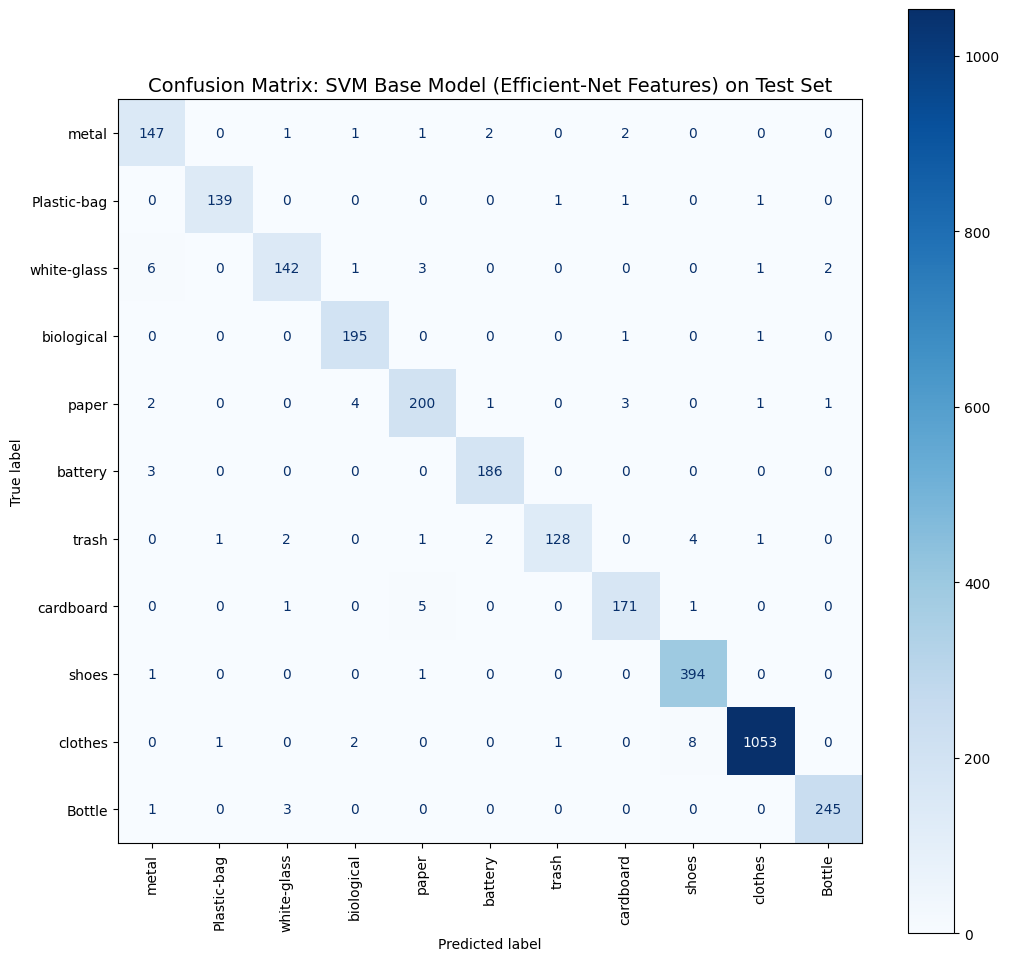


Ma trận nhầm lẫn đã được tính toán và lưu thành công dưới dạng file: confusion_matrix_svm_baseline_test.png


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Tính toán Ma trận nhầm lẫn
num_classes = len(classes)
all_labels = list(range(num_classes)) 

cm = confusion_matrix(
    y_test, 
    y_pred_test, 
    labels=all_labels # Đảm bảo ma trận có kích thước 11x11
)

# 2. Trực quan hóa Ma trận nhầm lẫn
print("="*60)
print("MA TRẬN NHẦM LẪN (CONFUSION MATRIX) TRÊN TẬP TEST")
print("="*60)

# Khởi tạo figure
fig, ax = plt.subplots(figsize=(12, 12)) 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

# Hiển thị ma trận
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', ax=ax)
plt.title('Confusion Matrix: SVM Base Model (Efficient-Net Features) on Test Set', fontsize=14)


# 3. Lưu hình ảnh
file_name = "confusion_matrix_svm_baseline_test.png" 
plt.savefig(file_name, bbox_inches='tight', dpi=300) 

plt.show() 

print(f"\nMa trận nhầm lẫn đã được tính toán và lưu thành công dưới dạng file: {file_name}")

HIỂN THỊ 2 ẢNH ĐƯỢC PHÂN LOẠI ĐÚNG NGẪU NHIÊN TRÊN TẬP TEST (Tổng: 3000 ảnh)


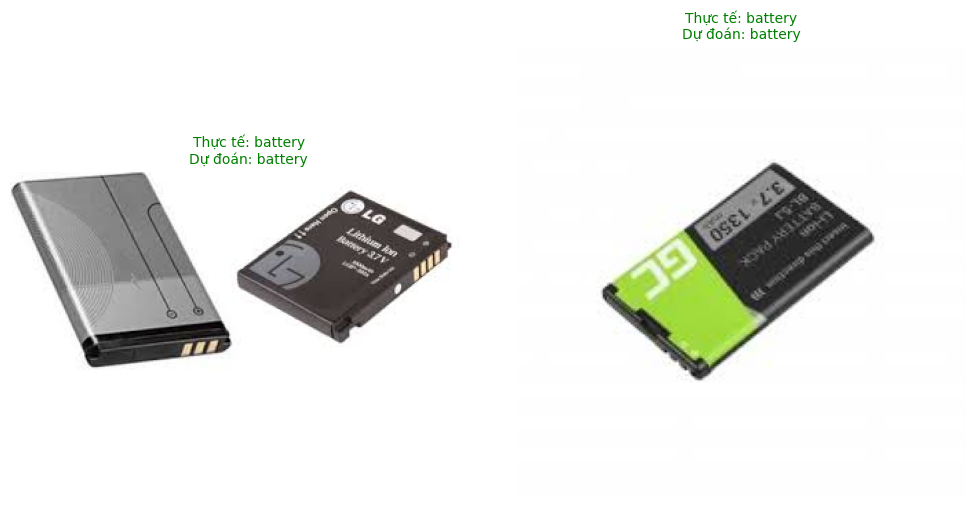

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

correctly_classified_mask = (y_test == y_pred_test)
indices_in_test_set = np.where(correctly_classified_mask)[0]
num_correctly_classified = len(indices_in_test_set)

print(f"HIỂN THỊ 2 ẢNH ĐƯỢC PHÂN LOẠI ĐÚNG NGẪU NHIÊN TRÊN TẬP TEST (Tổng: {num_correctly_classified} ảnh)")

# Chọn số lượng ảnh muốn hiển thị

num_to_display = min(2, num_correctly_classified) 

if num_correctly_classified > 0:
    # Lấy ngẫu nhiên 'num_to_display' chỉ mục
    random_correct_indices = np.random.choice(
        indices_in_test_set, 
        size=num_to_display, 
        replace=False 
    )
    
    # Khởi tạo figure chỉ khi có mẫu để hiển thị
    fig, axes = plt.subplots(1, num_to_display, figsize=(10, 5))
    
    # Xử lý trường hợp chỉ hiển thị 1 ảnh
    if num_to_display == 1:
        axes = [axes] 

    for i in range(num_to_display):
        # Lấy chỉ mục đã chọn ngẫu nhiên
        test_idx = random_correct_indices[i] 
        
        # Lấy thông tin nhãn
        true_label = y_test[test_idx]
        pred_label = y_pred_test[test_idx]
        true_class_name = classes[true_label]
        predicted_class_name = classes[pred_label]
        
        # *** ĐỌC ẢNH GỐC TỪ ĐƯỜNG DẪN paths_test ***
        image_path = paths_test[test_idx] 
        image = cv2.imread(image_path)
        
        if image is None:
            image_rgb = np.zeros((128, 128, 3), dtype=np.uint8) 
            title_color = 'gray'
        else:
            # Chuyển từ BGR (OpenCV) sang RGB (Matplotlib)
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            # Màu xanh lá cho dự đoán đúng
            title_color = 'green' 
        
        # Hiển thị ảnh
        axes[i].imshow(image_rgb)
        axes[i].set_title(f"Thực tế: {true_class_name}\nDự đoán: {predicted_class_name}", 
                          color=title_color, fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

else:
    print(" Không có bất kỳ mẫu nào được phân loại đúng trong tập Test. Không thể hiển thị hình ảnh.")

HIỂN THỊ 2 ẢNH BỊ PHÂN LOẠI SAI NGẪU NHIÊN TRÊN TẬP TEST (Tổng: 76 ảnh)


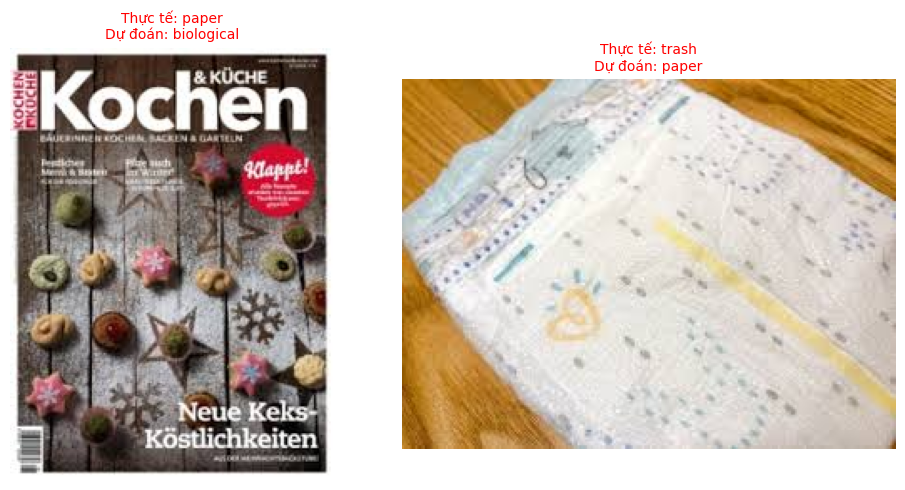

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

# 1. Tìm các chỉ mục (indices) nơi dự đoán SAI

misclassified_mask = (y_test != y_pred_test)
indices_in_test_set = np.where(misclassified_mask)[0]
num_misclassified = len(indices_in_test_set)

print(f"HIỂN THỊ 2 ẢNH BỊ PHÂN LOẠI SAI NGẪU NHIÊN TRÊN TẬP TEST (Tổng: {num_misclassified} ảnh)")

# Chọn số lượng ảnh muốn hiển thị

num_to_display = min(2, num_misclassified) 

if num_misclassified > 0:
    # Lấy ngẫu nhiên 'num_to_display' chỉ mục
    random_misclassified_indices = np.random.choice(
        indices_in_test_set, 
        size=num_to_display, 
        replace=False 
    )
    
    # Khởi tạo figure chỉ khi có mẫu để hiển thị
    fig, axes = plt.subplots(1, num_to_display, figsize=(10, 5))
    
    # Xử lý trường hợp chỉ hiển thị 1 ảnh
    if num_to_display == 1:
        axes = [axes] 

    for i in range(num_to_display):
        # Lấy chỉ mục đã chọn ngẫu nhiên
        test_idx = random_misclassified_indices[i] 
        
        # Lấy thông tin nhãn
        true_label = y_test[test_idx]
        pred_label = y_pred_test[test_idx]
        true_class_name = classes[true_label]
        predicted_class_name = classes[pred_label]
        
        # *** ĐỌC ẢNH GỐC TỪ ĐƯỜNG DẪN paths_test ***
        image_path = paths_test[test_idx] 
        image = cv2.imread(image_path)
        
        if image is None:
            image_rgb = np.zeros((128, 128, 3), dtype=np.uint8) 
            title_color = 'gray'
        else:
            # Chuyển từ BGR (OpenCV) sang RGB (Matplotlib)
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            # Màu đỏ cho dự đoán sai
            title_color = 'red' 
        
        # Hiển thị ảnh
        axes[i].imshow(image_rgb)
        axes[i].set_title(f"Thực tế: {true_class_name}\nDự đoán: {predicted_class_name}", 
                          color=title_color, fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

else:
    print("Không có mẫu nào bị phân loại sai trong tập Test. (Chúc mừng! Hoặc kiểm tra lại dữ liệu). Không thể hiển thị hình ảnh.")

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import time

# BƯỚC 1: XÁC ĐỊNH LƯỚI THAM SỐ VÀ KHỞI TẠO GRID SEARCH
# Phạm vi các giá trị C và gamma cần thử nghiệm
param_grid = {
    'C': [0.1, 1, 10,100], 
    'gamma': ['scale', 0.01, 0.1], 
    'kernel': ['rbf'] 
}

base_svm = SVC(random_state=42)

print("="*60)
print("BẮT ĐẦU TỐI ƯU THAM SỐ SVM (GRID SEARCH CV) TRÊN TẬP TRAIN")
print("="*60)
start_time = time.time()

# Grid Search sẽ tìm kiếm tham số tốt nhất qua 3-fold Cross-Validation trên X_train
grid_search = GridSearchCV(
    estimator=base_svm, 
    param_grid=param_grid, 
    cv=3, 
    verbose=2, 
    n_jobs=-1, # Sử dụng tất cả các lõi CPU
    scoring='accuracy' 
)

# Chạy tìm kiếm
grid_search.fit(X_train, y_train)

end_time = time.time()
print(f"\nThời gian chạy Grid Search: {end_time - start_time:.2f} giây")

# BƯỚC 2: ĐÁNH GIÁ MÔ HÌNH TỐT NHẤT TRÊN TẬP TEST

# Lấy mô hình SVM tốt nhất đã được tối ưu
best_svm_model = grid_search.best_estimator_

print(f"Tham số TỐT NHẤT tìm được: {grid_search.best_params_}")
print(f"Độ chính xác TỐT NHẤT (Cross-Validation trên Train): {grid_search.best_score_:.4f}")

# Dự đoán trên tập Test BẰNG MÔ HÌNH TỐT NHẤT
y_pred_final = best_svm_model.predict(X_test)

# 1. Độ chính xác cuối cùng
final_accuracy = accuracy_score(y_test, y_pred_final)
print(f"Độ chính xác CUỐI CÙNG trên tập TEST: {final_accuracy:.4f}")

# 2. Báo cáo Phân loại cuối cùng
num_classes = len(classes)
all_labels = list(range(num_classes)) 

print("\nClassification Report trên Test:")
print(classification_report(y_test, y_pred_final, target_names=classes, labels=all_labels))

BẮT ĐẦU TỐI ƯU THAM SỐ SVM (GRID SEARCH CV) TRÊN TẬP TRAIN
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Thời gian chạy Grid Search: 840.42 giây
Tham số TỐT NHẤT tìm được: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Độ chính xác TỐT NHẤT (Cross-Validation trên Train): 0.9724
Độ chính xác CUỐI CÙNG trên tập TEST: 0.9766

Classification Report trên Test:
              precision    recall  f1-score   support

       metal       0.92      0.96      0.94       154
 Plastic-bag       0.99      0.98      0.98       142
 white-glass       0.97      0.92      0.94       155
  biological       0.96      0.99      0.97       197
       paper       0.96      0.95      0.95       212
     battery       0.97      0.98      0.98       189
       trash       0.98      0.92      0.95       139
   cardboard       0.97      0.97      0.97       178
       shoes       0.97      0.99      0.98       396
     clothes       0.99      0.99      0.99      1065
      Bottle       0.99      0.99

MA TRẬN NHẦM LẪN (CONFUSION MATRIX) CHO MÔ HÌNH TỐI ƯU TRÊN TẬP TEST


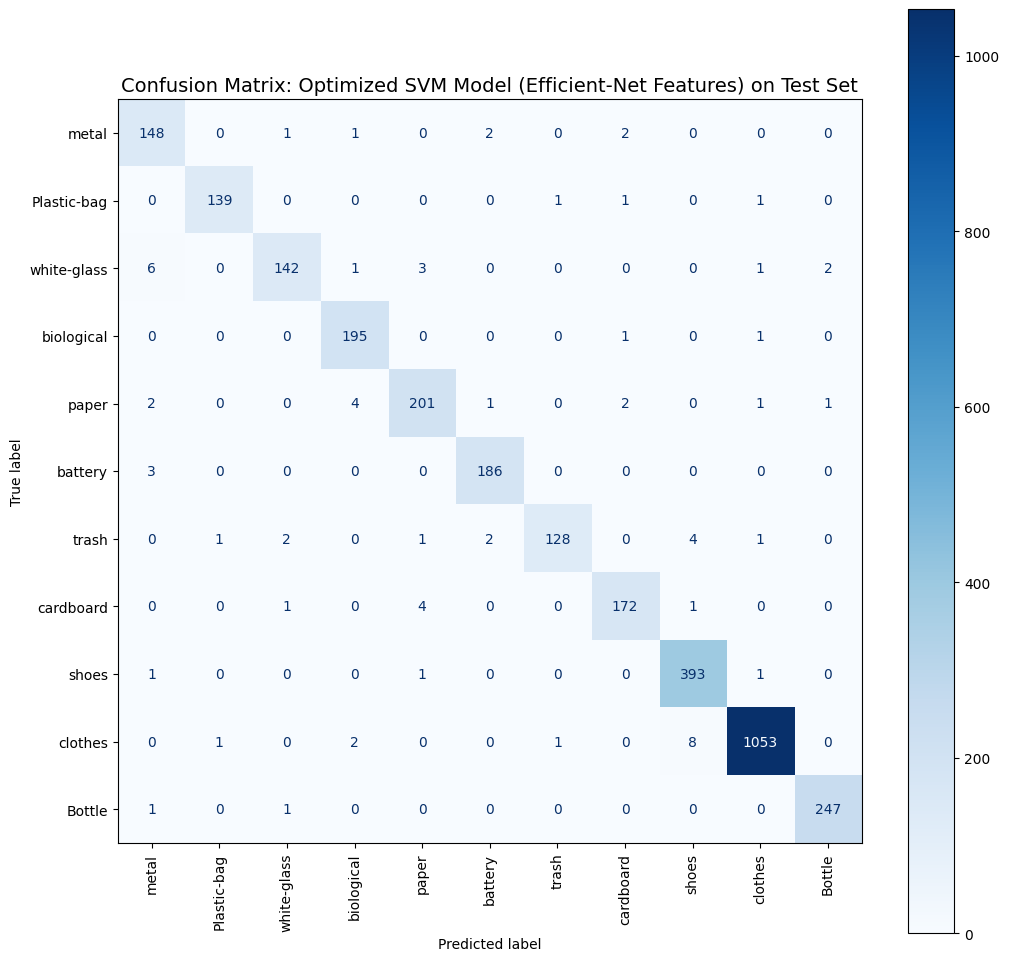


Ma trận nhầm lẫn đã được tính toán và lưu thành công dưới dạng file: confusion_matrix_svm_optimized_hist_test.png


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Tính toán Ma trận nhầm lẫn
num_classes = len(classes)
all_labels = list(range(num_classes)) 

cm = confusion_matrix(
    y_test, 
    y_pred_final, 
    labels=all_labels # Đảm bảo ma trận có kích thước đầy đủ
)

# 2. Trực quan hóa Ma trận nhầm lẫn
print("MA TRẬN NHẦM LẪN (CONFUSION MATRIX) CHO MÔ HÌNH TỐI ƯU TRÊN TẬP TEST")

# Khởi tạo figure
fig, ax = plt.subplots(figsize=(12, 12)) 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes) 

# Hiển thị ma trận
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', ax=ax)
plt.title('Confusion Matrix: Optimized SVM Model (Efficient-Net Features) on Test Set', fontsize=14)

# 3. Lưu hình ảnh
file_name = "confusion_matrix_svm_optimized_hist_test.png" 
plt.savefig(file_name, bbox_inches='tight', dpi=300) 

plt.show() 

print(f"\nMa trận nhầm lẫn đã được tính toán và lưu thành công dưới dạng file: {file_name}")

In [18]:
import joblib
import os 
import time

timestamp = time.strftime("%Y%m%d_%H%M%S")
file_name = f"best_svm_EfficientNet_model_{timestamp}.joblib"

# BƯỚC 1: LƯU MÔ HÌNH
print("="*60)
print(f"BẮT ĐẦU LƯU MÔ HÌNH SVM TỐT NHẤT")
print("="*60)

try:
    # Lưu mô hình (và các tham số đã được tối ưu) vào file
    joblib.dump(best_svm_model, file_name)
    
    print(f"Mô hình đã được lưu thành công tại: {os.path.abspath(file_name)}")
    print(f"Tham số: {best_svm_model.get_params()}")
except Exception as e:
    print(f"Lỗi khi lưu mô hình: {e}")


BẮT ĐẦU LƯU MÔ HÌNH SVM TỐT NHẤT
✅ Mô hình đã được lưu thành công tại: /kaggle/working/best_svm_EfficientNet_model_20260119_125701.joblib
Tham số: {'C': 10, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time= 1.3min
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time= 2.5min
[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time=  59.6s
[CV] END .........................C=1, gamma=0.1, kernel=rbf; total time= 2.5min
[CV] END .......................C=10, gamma=0.01, kernel=rbf; total time= 1.0min
[CV] END ........................C=10, gamma=0.1, kernel=rbf; total time= 2.7min
[CV] END ......................C=100, gamma=0.01, kernel=rbf; total time= 1.0min
[CV] END 